<a href="https://colab.research.google.com/github/Awabhssn/My-work/blob/main/covid_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn


In [ ]:
df = pd.read_csv('/content/owid-covid-data.csv')
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
1,AFG,Asia,Afghanistan,2020-01-01,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
2,AFG,Asia,Afghanistan,2020-01-02,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
3,AFG,Asia,Afghanistan,2020-01-03,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
4,AFG,Asia,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498


In [ ]:
df.isnull().sum()

,0
iso_code,265
continent,528
location,0
date,1
total_cases,341
new_cases,541
new_cases_smoothed,1117
total_deaths,341
new_deaths,541
new_deaths_smoothed,1117


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30822 entries, 0 to 30821
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   iso_code                         30557 non-null  object 
 1   continent                        30294 non-null  object 
 2   location                         30822 non-null  object 
 3   date                             30821 non-null  object 
 4   total_cases                      30481 non-null  float64
 5   new_cases                        30281 non-null  float64
 6   new_cases_smoothed               29705 non-null  float64
 7   total_deaths                     30481 non-null  float64
 8   new_deaths                       30281 non-null  float64
 9   new_deaths_smoothed              29705 non-null  float64
 10  total_cases_per_million          30217 non-null  float64
 11  new_cases_per_million            30217 non-null  float64
 12  new_cases_smoothed

In [ ]:
df = df.dropna(subset=["date"])
df["continent"] = df["continent"].fillna("Unknown")
df["date"] = pd.to_datetime(df["date"], errors='coerce')

In [ ]:

df = df.sort_values(["location", "date"])

daily_cols = [
    "new_cases", "new_deaths",
    "new_cases_smoothed", "new_deaths_smoothed"
]

df[daily_cols] = (
    df.groupby("location")[daily_cols]
      .fillna(0)
)


/tmp/ipython-input-2994323157.py:10: FutureWarning: DataFrameGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use DataFrame.fillna instead
  .fillna(0)


In [ ]:
total_cols = ["total_cases", "total_deaths"]

df[total_cols] = (
    df.groupby("location")[total_cols]
      .ffill()
)

In [ ]:
test_cols = [
    "new_tests", "total_tests",
    "positive_rate", "tests_per_case"
]

In [ ]:
static_cols = [
    "population", "gdp_per_capita",
    "median_age", "life_expectancy"
]

for col in static_cols:
    df[col] = (
        df.groupby("location")[col]
          .transform(lambda x: x.fillna(x.median()))
    )

In [ ]:
health_cols = [
    "diabetes_prevalence",
    "cardiovasc_death_rate",
    "female_smokers",
    "male_smokers",
    "hospital_beds_per_thousand"
]

for col in health_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-1588163488.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df.isna().mean().sort_values(ascending=False).head(10)

,0
new_tests,0.683722
new_tests_per_thousand,0.683722
total_tests,0.677752
total_tests_per_thousand,0.677752
tests_per_case,0.674865
positive_rate,0.667240
new_tests_smoothed,0.643392
new_tests_smoothed_per_thousand,0.643392
tests_units,0.625320
handwashing_facilities,0.578567


In [ ]:
df = df.dropna(how="all")

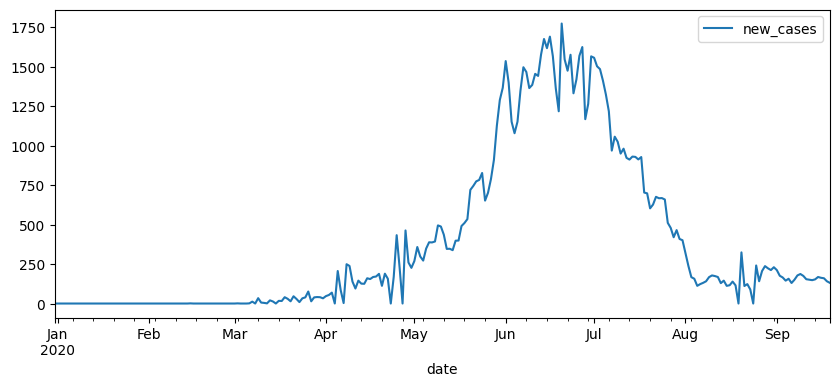

In [ ]:
import matplotlib.pyplot as plt

df[df["location"] == "Egypt"][["date", "new_cases"]].plot(
    x="date", y="new_cases", figsize=(10,4)
)
plt.show()

In [ ]:
df["date"] = pd.to_datetime(df["date"])

In [ ]:
powerbi_cols = [
    "location", "date", "continent",
    "total_cases", "new_cases", "total_deaths", "new_deaths",
    "population", "gdp_per_capita", "life_expectancy",
    "diabetes_prevalence", "cardiovasc_death_rate"
]

powerbi_cols = [c for c in powerbi_cols if c in df.columns]
df_pb = df[powerbi_cols]

In [ ]:
df_pb = df_pb.sort_values(["location", "date"])

In [ ]:
df_pb.reset_index(drop=True, inplace=True)

In [ ]:
df_pb.to_csv(
    "covid_powerbi_clean.csv",
    index=False,
    encoding="utf-8"
)